# MeteoSwiss OGD — Local Forecast Meteogram

This notebook shows you how to access and visualise local weather forecast data
from the [MeteoSwiss Open Government Data (OGD)](https://opendatadocs.meteoswiss.ch/) collection.

By the end you will know how to:
1. Discover which forecast locations and parameters MeteoSwiss publishes
2. Download a 9-day forecast for any Swiss location via the STAC API
3. Parse the CSV files into tidy pandas DataFrames
4. Produce a meteogram and a daily summary table

**Data source:** `ch.meteoschweiz.ogd-local-forecasting` — updated hourly  
**STAC API:** https://data.geo.admin.ch/api/stac/v1

## 0 · Setup

Standard library imports and a single network call to fetch the **parameter metadata**
(units, descriptions, hourly vs. daily granularity) that we will use throughout the notebook.

In [21]:
import httpx
import pandas as pd
from io import StringIO
from datetime import datetime
from zoneinfo import ZoneInfo

# Plotting module — lives alongside this notebook
from meteogram_plot import plot_meteogram

# ---------------------------------------------------------------------------
# API endpoints
# ---------------------------------------------------------------------------
STAC_BASE_URL  = "https://data.geo.admin.ch/api/stac/v1"
COLLECTION_ID  = "ch.meteoschweiz.ogd-local-forecasting"
METADATA_URL   = (
    f"https://data.geo.admin.ch/{COLLECTION_ID}/"
    "ogd-local-forecasting_meta_parameters.csv"
)
POI_LIST_URL   = (
    f"https://data.geo.admin.ch/{COLLECTION_ID}/"
    "ogd-local-forecasting_meta_point.csv"
)
PICTO_URL = (
    "https://www.meteoswiss.admin.ch/dam/jcr:bfcea855-ab6b-4602-9d8b-0464afa30e66/"
    "2022-02-14-Wetter-Icons-inkl-beschreibung-v1-an-website.xlsx"
)

LOCAL_TZ = ZoneInfo("Europe/Zurich")

# ---------------------------------------------------------------------------
# Load parameter metadata
# ---------------------------------------------------------------------------
resp = httpx.get(METADATA_URL, follow_redirects=True, timeout=30)
resp.raise_for_status()
meta_df = pd.read_csv(StringIO(resp.content.decode("latin-1")), sep=";")

PARAM_UNITS        = dict(zip(meta_df["parameter_shortname"], meta_df["parameter_unit"]))
PARAM_GROUP        = dict(zip(meta_df["parameter_shortname"], meta_df["parameter_group_en"]))
DAILY_PARAMS       = set(meta_df.loc[meta_df["parameter_granularity"] == "D", "parameter_shortname"])

print(f"✓ {len(meta_df)} parameters loaded from OGD metadata")

✓ 32 parameters loaded from OGD metadata


## 1 · Choose your location

The forecast is organised by **point of interest (POI)**.  
Use the searchable table below to find your city or postal code, then copy the
`point_id` into the configuration cell that follows.

In [22]:
import itables
from itables import show

# Load the POI metadata
df_pois = pd.read_csv(POI_LIST_URL, sep=";", encoding="latin-1")

print(f"✓ {len(df_pois)} forecast locations available")
print("Search the table below to find your location, then copy its point_id and point_type_id.\n")

# Configure itables for a nice searchable display
itables.options.classes  = ["display", "nowrap", "compact"]
itables.options.maxBytes = 0

# Display relevant columns for the user to choose from
show(df_pois[["point_id", "point_type_id", "point_name", "postal_code", "point_type_en", "station_abbr"]],
     scrollX=True, lengthMenu=[5, 10, 20])

✓ 5629 forecast locations available
Search the table below to find your location, then copy its point_id and point_type_id.



Loading ITables v2.8.1 from the internet... (need help?)


In [23]:
# ── User configuration ────────────────────────────────────────────────────
POI_ID   = "118802"         # point_id from the table above
POI_TYPE_ID = "2"        # point_type_id from the table above
LANG  = "en"             # label language: "de", "fr", "it", "en"
PANELS = "all"           # "all"  or a list e.g. ["Temperature", "Wind"]
# ─────────────────────────────────────────────────────────────────────────

PANEL_ORDER = ["Temperature", "Precipitation", "Wind", "Sunshine", "Radiation", "Clouds"]

selected_panels = PANEL_ORDER if PANELS == "all" else (
    [PANELS] if isinstance(PANELS, str) else PANELS
)

# Parameters the summary table always needs, regardless of panel selection
SUMMARY_PARAMS  = ["jp2000d0", "tre200pn", "tre200px", "rreq10p0", "rreq90p0"]
# Parameters only available at official weather stations — exclude for POI forecasts
EXCLUDE_PARAMS  = {"rka150d0", "tre200dn", "tre200dx"}

selected_params = [
    p for p, group in PARAM_GROUP.items()
    if group in selected_panels and p not in EXCLUDE_PARAMS
]
all_params = list(dict.fromkeys(selected_params + SUMMARY_PARAMS))

print(f"POI {POI_ID} | language: {LANG} | panels: {', '.join(selected_panels)}")
print(f"Parameters to fetch: {len(all_params)}")

POI 118802 | language: en | panels: Temperature, Precipitation, Wind, Sunshine, Radiation, Clouds
Parameters to fetch: 28


## 2 · Explore available parameters

Before downloading anything, let's look at what MeteoSwiss actually publishes for
local forecasts.  Each parameter has a **shortname** (used as the CSV column name),
a human-readable description, a unit, and a granularity (hourly `H` or daily `D`).

Parameters marked `✓` will be included in the download below.

In [24]:
desc_col  = f"parameter_description_{LANG}"
group_col = f"parameter_group_{LANG}"

# Fall back to English if the requested language is unavailable
if desc_col not in meta_df.columns:
    print(f"⚠ Language '{LANG}' not available — using English")
    desc_col, group_col = "parameter_description_en", "parameter_group_en"

df_overview = meta_df[["parameter_shortname", desc_col, group_col,
                        "parameter_unit", "parameter_granularity"]].copy()
df_overview.columns = ["Shortname", "Description", "Panel", "Unit", "Granularity"]
df_overview["Selected"] = df_overview["Shortname"].isin(all_params).map({True: "✓", False: ""})

panel_rank = {p: i for i, p in enumerate(PANEL_ORDER)}
df_overview = (
    df_overview
    .assign(_rank=df_overview["Panel"].map(panel_rank).fillna(99))
    .sort_values(["_rank", "Shortname"])
    .drop(columns="_rank")
)

print(f"{'='*80}")
for panel in PANEL_ORDER:
    rows = df_overview[df_overview["Panel"] == panel]
    if rows.empty:
        continue
    print(f"\n  {panel.upper()}")
    print(f"  {'-'*76}")
    for _, row in rows.iterrows():
        gran = "hourly" if row["Granularity"] == "H" else "daily "
        print(f"  {row['Selected']:>1}  {row['Shortname']:<12} {gran}  "
              f"{row['Unit']:<8} {row['Description']}")


  TEMPERATURE
  ----------------------------------------------------------------------------
     tre200dn     daily   °C       Air temperature 2 m above ground; daily minimum
     tre200dx     daily   °C       Air temperature 2 m above ground; daily maximum
  ✓  tre200h0     hourly  °C       Air temperature 2 m above ground; hourly mean
  ✓  tre200pn     daily   °C       Air temperature 2 m above ground; daily minimum 00:00 - 24:00 local time
  ✓  tre200px     daily   °C       Air temperature 2 m above ground; daily maximum 00:00 - 24:00 local time
  ✓  treq10h0     hourly  °C       Air temperature 2 m above ground; hourly mean, 10% quantile
  ✓  treq90h0     hourly  °C       Air temperature 2 m above ground; hourly mean, 90% quantile
  ✓  zprfr0hs     hourly  m        Zero degree level; hourly value, forecast

  PRECIPITATION
  ----------------------------------------------------------------------------
     rka150d0     daily   mm       Precipitation; daily total 0 UTC - 0 UTC
  ✓ 

## 3 · Download the forecast data

MeteoSwiss publishes its forecast data as a **STAC collection**.  
Each day's forecast is a STAC **item**; each parameter is a **STAC asset** (a CSV file).

The download has three steps:
1. Fetch today's STAC item to get the asset URLs
2. Download one CSV per parameter
3. Filter each CSV to keep only our point of interest

In [25]:
# Step 1 — Fetch today's STAC item
today_id = f"{datetime.now(LOCAL_TZ).strftime('%Y%m%d')}-ch"
item_url = f"{STAC_BASE_URL}/collections/{COLLECTION_ID}/items/{today_id}"

with httpx.Client() as client:
    item = client.get(item_url)
    item.raise_for_status()
    stac_item = item.json()

assets = stac_item["assets"]

# Sort assets to find the latest run time available in this item
# Filename pattern: vnut12.lssw.YYYYMMDDHHmm.<param>.csv
all_runs = sorted({key.split(".")[2] for key in assets})
latest_run = all_runs[-1]

runtime_dt = (
    datetime.strptime(latest_run, "%Y%m%d%H%M")
    .replace(tzinfo=ZoneInfo("UTC"))
    .astimezone(LOCAL_TZ)
)

print(f"✓ STAC item:  {today_id} (Production Date)")
print(f"  Latest Run: {runtime_dt.strftime('%Y-%m-%d %H:%M %Z')} (from {len(all_runs)} runs today)")
print(f"  Assets:     {len(assets)} total files in this item")

✓ STAC item:  20260629-ch (Production Date)
  Latest Run: 2026-06-29 11:00 CEST (from 3 runs today)
  Assets:     96 total files in this item


In [26]:
# Resolve the chosen POI against the point metadata using both IDs
poi_match = df_pois[
    (df_pois["point_id"] == int(POI_ID)) &
    (df_pois["point_type_id"] == int(POI_TYPE_ID))
]

if poi_match.empty:
    raise ValueError(f"Location with point_id {POI_ID} and point_type_id {POI_TYPE_ID} not found.")

poi_row  = poi_match.iloc[0]
poi_name = poi_row["point_name"]
if "point_height_masl" in poi_row:
    elev_str = f", {poi_row['point_height_masl']:.0f} m a.s.l."
else:
    elev_str = ""

print(f"✓ Selected POI: {POI_ID} (Type {POI_TYPE_ID}) — {poi_name}{elev_str}")

# Map each parameter we want to its asset URL (this logic remains the same)
param_urls = {}
for param in all_params:
    for key, asset in assets.items():
        if param in key:
            param_urls[param] = asset["href"]
            break

print(f"\n{len(param_urls)}/{len(all_params)} parameters matched to asset URLs")

✓ Selected POI: 118802 (Type 2) — St-George, 925 m a.s.l.

28/28 parameters matched to asset URLs


In [27]:
# Step 2 — Download all parameter CSVs
raw_data = {}
with httpx.Client(timeout=30.0) as client:
    for param, url in param_urls.items():
        resp = client.get(url)
        if resp.status_code == 200:
            raw_data[param] = resp.content
        else:
            print(f"  ⚠ HTTP {resp.status_code} for {param}")

print(f"✓ Downloaded {len(raw_data)}/{len(param_urls)} files")

✓ Downloaded 28/28 files


In [28]:
# Step 3 — Parse CSVs and filter to our POI
#
# Each CSV contains data for *all* POIs.  We keep only the row(s) matching
# our point_id, then parse the timestamp column and pivot into two DataFrames:
#   df_hourly  — one column per hourly parameter, time-indexed
#   df_daily   — one column per daily  parameter, date-indexed

def parse_parameter_csv(content: bytes, param: str, poi_id: str, poi_type_id: str, tz) -> pd.DataFrame:
    """Parse a single parameter CSV and return a time-indexed Series for the unique POI."""
    df = pd.read_csv(StringIO(content.decode("latin-1")), sep=";")
    # Filter by both IDs to ensure uniqueness
    # Note: Column names in data CSVs are usually 'point_id' and 'point_type_id'
    df = df[
        (df["point_id"].astype(str) == poi_id) &
        (df["point_type_id"].astype(str) == poi_type_id)
    ]
    if df.empty:
        return pd.DataFrame()
    # Identify the timestamp column (named "date" or "time")
    time_col = next(c for c in df.columns if c.lower() in ("date", "time"))
    df[time_col] = (
        pd.to_datetime(df[time_col].astype(int).astype(str), format="%Y%m%d%H%M", utc=True)
        .dt.tz_convert(tz)
    )
    series = df.set_index(time_col)[[param]]
    series[param] = pd.to_numeric(series[param], errors="coerce")
    return series
# --- Execute Parsing ---
poi_id      = str(poi_row["point_id"])
poi_type_id = str(poi_row["point_type_id"])
dfs_hourly  = {}
dfs_daily   = {}
for param, content in raw_data.items():
    try:
        series = parse_parameter_csv(content, param, poi_id, poi_type_id, LOCAL_TZ)
        if series.empty:
            print(f"  ⚠ No data for POI {poi_id}/{poi_type_id} in {param}")
            continue
        if param in DAILY_PARAMS:
            series.index = series.index.normalize()
            dfs_daily[param] = series
        else:
            dfs_hourly[param] = series
    except Exception as e:
        print(f"  ⚠ Could not parse {param}: {e}")
df_hourly = pd.concat(dfs_hourly.values(), axis=1).sort_index() if dfs_hourly else pd.DataFrame()
df_daily  = pd.concat(dfs_daily.values(),  axis=1).sort_index() if dfs_daily  else pd.DataFrame()


print(f"✓ df_hourly: {df_hourly.shape[0]} timesteps × {df_hourly.shape[1]} parameters")
print(f"  Range: {df_hourly.index[0].strftime('%Y-%m-%d %H:%M')} → {df_hourly.index[-1].strftime('%Y-%m-%d %H:%M')}")
print(f"\n✓ df_daily:  {df_daily.shape[0]} days × {df_daily.shape[1]} parameters")
print(f"  Range: {df_daily.index[0].strftime('%Y-%m-%d')} → {df_daily.index[-1].strftime('%Y-%m-%d')}")
print("\nSample of df_hourly:")
display(df_hourly.head(3))

✓ df_hourly: 220 timesteps × 22 parameters
  Range: 2026-06-28 23:00 → 2026-07-08 02:00

✓ df_daily:  9 days × 6 parameters
  Range: 2026-06-29 → 2026-07-07

Sample of df_hourly:


,dkl010h0,fu3010h0,fu3010h1,fu3q10h0,fu3q10h1,fu3q90h0,fu3q90h1,gre000h0,nprohihs,nprolohs,...,rp0003i0,rre003i0,rre150h0,rreq10h0,rreq90h0,sre000h0,tre200h0,treq10h0,treq90h0,zprfr0hs
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-28 23:00:00+02:00,285,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,23.5,23.5,23.5,4257
2026-06-29 00:00:00+02:00,264,8.0,20.2,8.0,20.2,8.0,20.2,0,0.76,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,23.4,23.4,23.4,4235
2026-06-29 01:00:00+02:00,278,18.8,51.7,18.8,51.7,18.8,51.7,0,0.72,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,22.5,22.5,22.5,4204


## 4 · Visualise — Meteogram

The `plot_meteogram()` function assembles the multi-panel figure.  
All matplotlib code lives in `meteogram_plot.py` — open it if you want to
customise colours, panel layout, or add new weather variables.

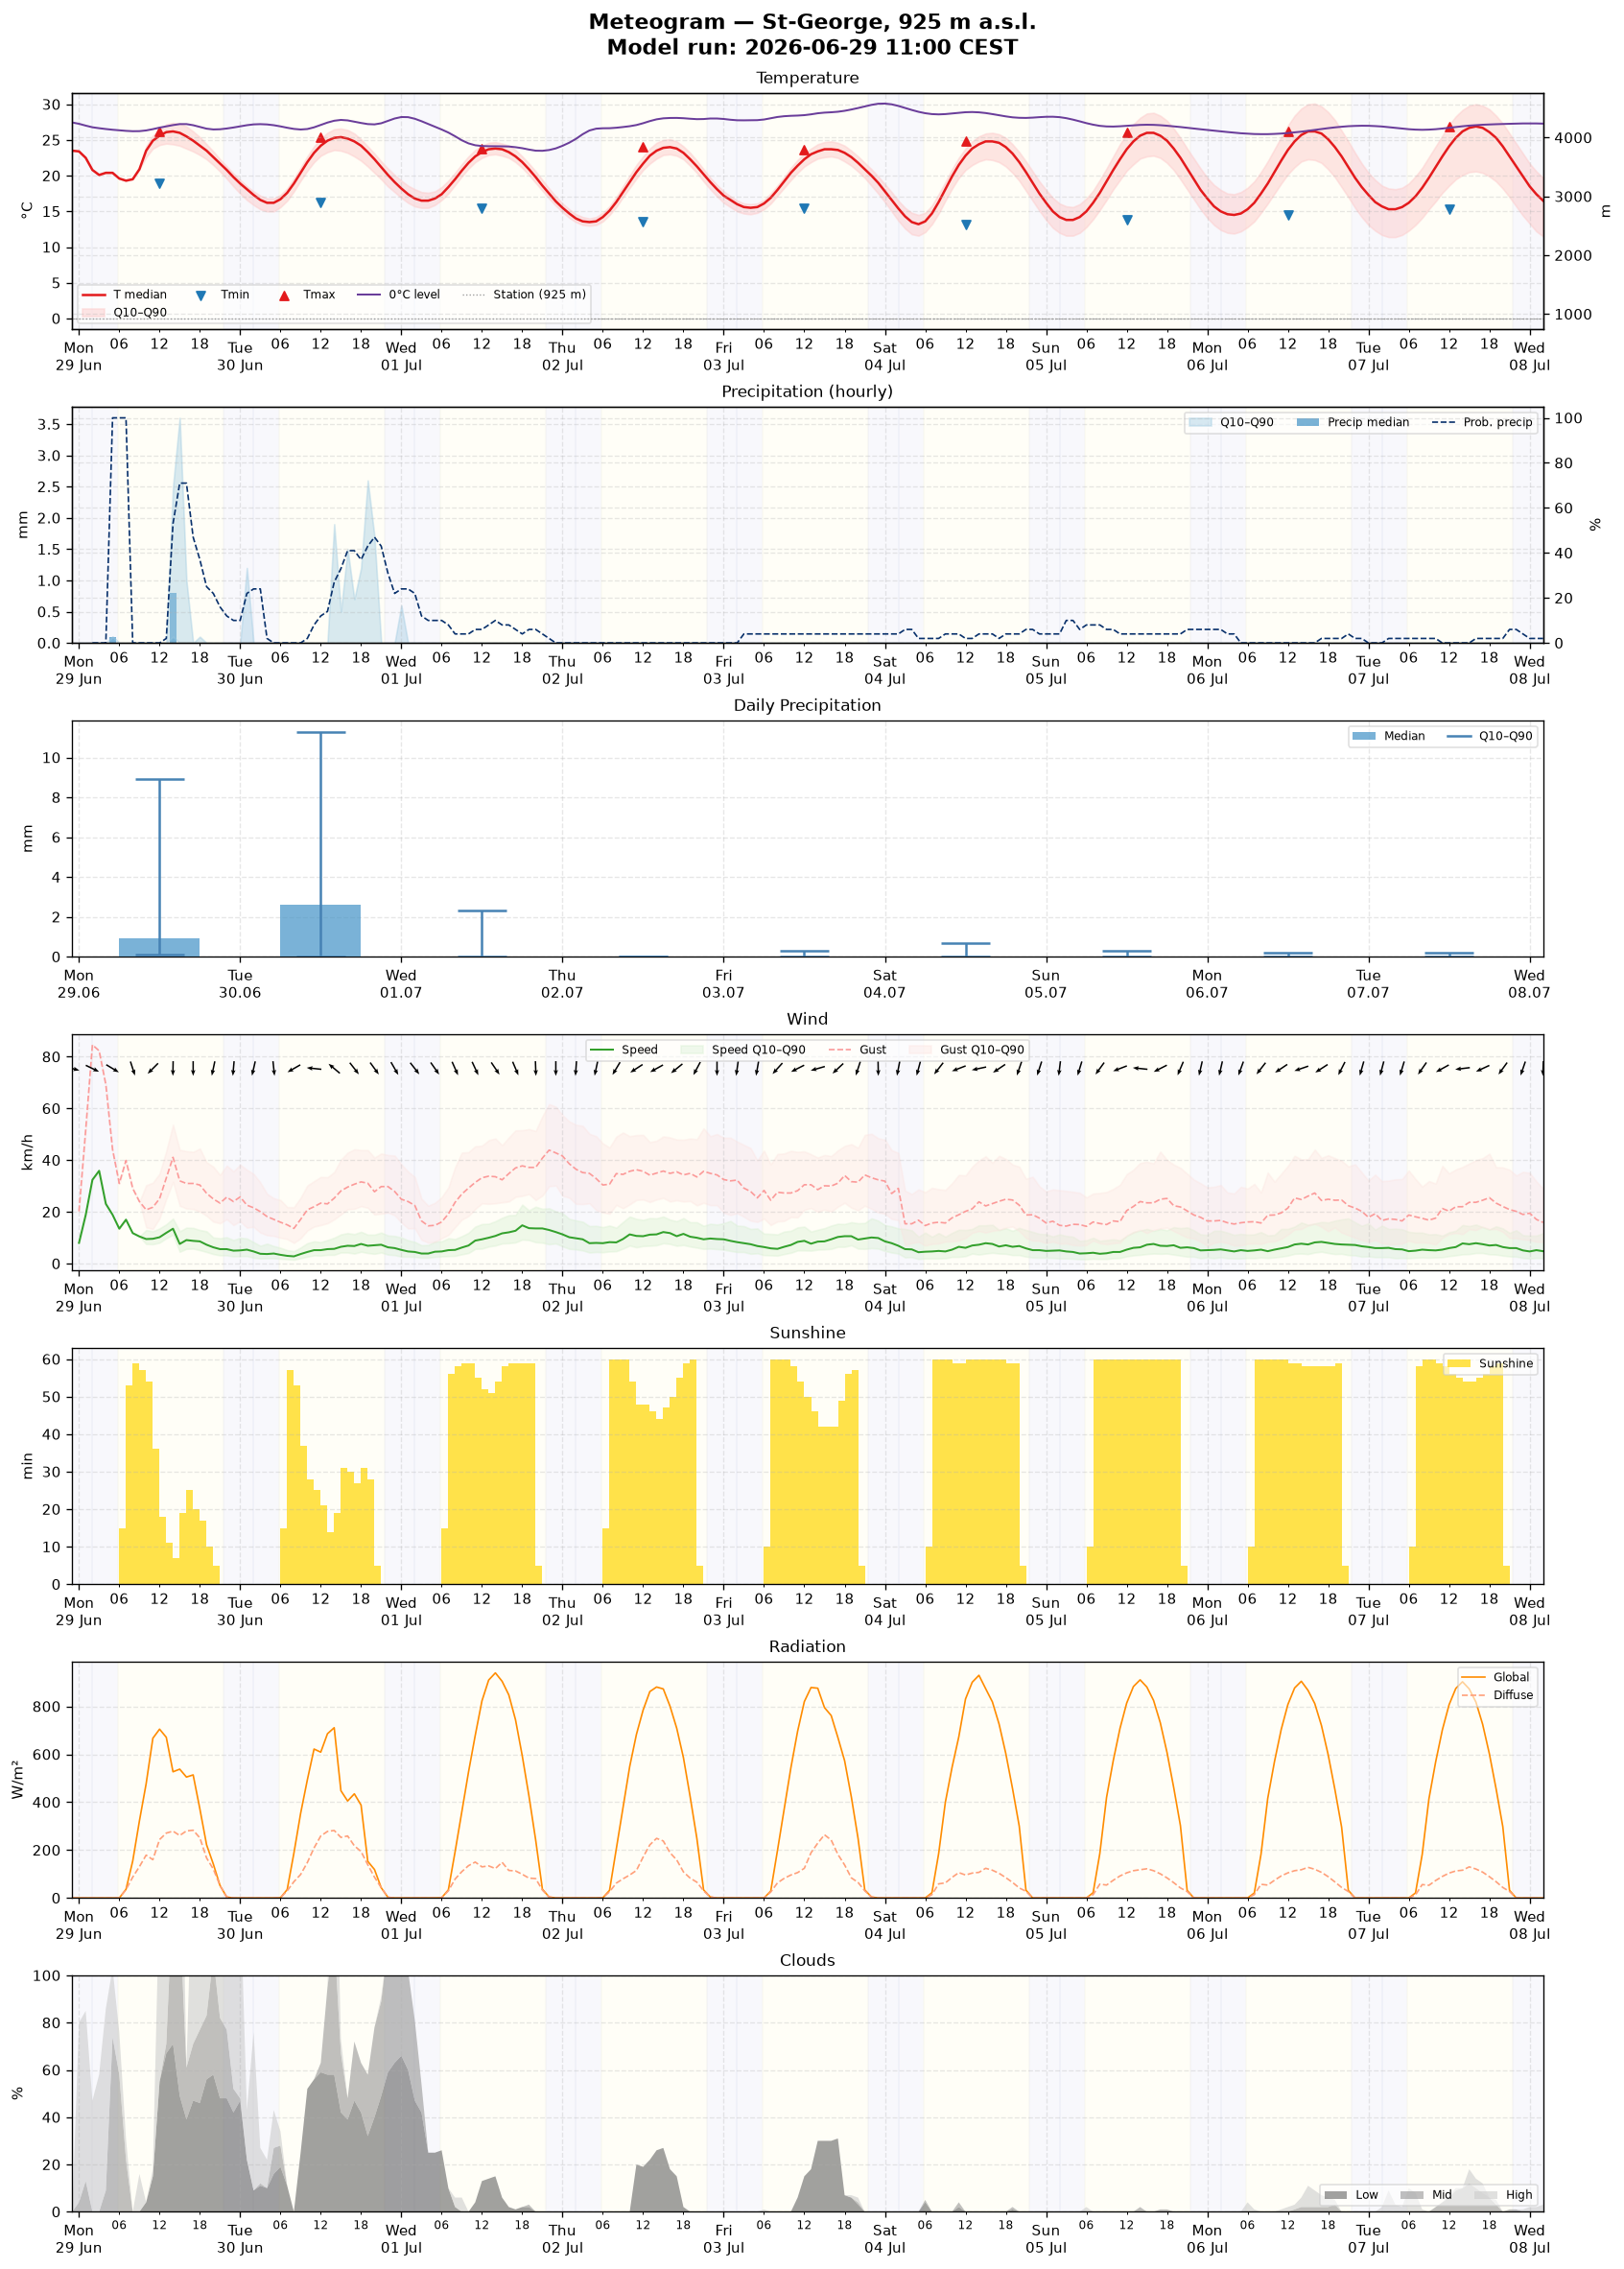

✓ Meteogram saved to meteogram.png


In [29]:
plot_meteogram(
    df_hourly  = df_hourly,
    df_daily   = df_daily,
    param_units= PARAM_UNITS,
    poi_row    = poi_row,
    poi_name   = poi_name,
    elev_str   = elev_str,
    runtime_dt = runtime_dt,
    local_tz   = LOCAL_TZ,
    panels     = selected_panels,
)

## 5 · Daily summary table

A compact 9-day overview: weather description (from MeteoSwiss pictogram codes),
min/max temperature, and precipitation range.

In [30]:
# Load pictogram descriptions from the MeteoSwiss Excel reference file
lang_col = {"de": 2, "fr": 3, "it": 4, "en": 5}.get(LANG, 5)
try:
    df_picto = pd.read_excel(PICTO_URL, sheet_name="aktuellste Version",
                             skiprows=4, header=None, engine="openpyxl")
    df_picto = (df_picto[[1, lang_col]]
                .dropna(subset=[1])
                .pipe(lambda d: d[pd.to_numeric(d[1], errors="coerce").notna()]))
    df_picto.columns = ["key", "description"]
    df_picto["key"]  = df_picto["key"].astype(int)
    picto_map = dict(zip(df_picto["key"], df_picto["description"].astype(str)))
    print(f"✓ {len(picto_map)} pictogram descriptions loaded ({LANG})")
except Exception as e:
    print(f"⚠ Could not load pictogram descriptions: {e}")
    picto_map = {}

rows = []
for date, row in df_daily.iterrows():
    code    = int(row["jp2000d0"]) if "jp2000d0" in df_daily and pd.notna(row.get("jp2000d0")) else None
    weather = picto_map.get(code, f"(code {code})") if code else "—"
    tmin    = f"{row['tre200pn']:.1f}" if "tre200pn" in df_daily and pd.notna(row.get("tre200pn")) else "—"
    tmax    = f"{row['tre200px']:.1f}" if "tre200px" in df_daily and pd.notna(row.get("tre200px")) else "—"
    if "rreq10p0" in df_daily and "rreq90p0" in df_daily:
        q10, q90 = max(0, row["rreq10p0"]), max(0, row["rreq90p0"])
        precip   = "0" if q10 == 0 and q90 == 0 else f"{q10:.0f}–{q90:.0f}"
    else:
        precip = "—"
    rows.append({"Date": date.strftime("%a %d.%m"), "Weather": weather,
                 "T min (°C)": tmin, "T max (°C)": tmax, "Precip. (mm)": precip})

df_summary = pd.DataFrame(rows)
print(f"\n📋 Daily forecast — {poi_name}{elev_str}")
print(f"🕐 Model run: {runtime_dt.strftime('%Y-%m-%d %H:%M %Z')}\n")
print(df_summary.to_string(index=False))

✓ 84 pictogram descriptions loaded (en)

📋 Daily forecast — St-George, 925 m a.s.l.
🕐 Model run: 2026-06-29 11:00 CEST

     Date                                  Weather T min (°C) T max (°C) Precip. (mm)
Mon 29.06            partly sunny, slightly stormy       18.9       26.2          0–9
Tue 30.06 sunny intervals, chance of thunderstorms       16.2       25.4         0–11
Wed 01.07                mostly sunny, some clouds       15.5       23.8          0–2
Thu 02.07                                    sunny       13.5       24.0            0
Fri 03.07                mostly sunny, some clouds       15.5       23.7          0–0
Sat 04.07                                    sunny       13.2       24.8          0–1
Sun 05.07                                    sunny       13.8       26.0          0–0
Mon 06.07                                    sunny       14.5       26.2          0–0
Tue 07.07                mostly sunny, some clouds       15.3       26.9          0–0


## Next steps

- **Other collections:** Explore `ch.meteoschweiz.ogd-surface-derived-gridded` for gridded products.
- **More parameters:** Edit `PANELS` in the configuration cell to show or hide weather variables.
- **Custom visualisation:** All chart code is in `meteogram_plot.py` — extend it freely.
- **OGD documentation:** https://meteoswiss.atlassian.net/wiki/spaces/DAT/pages/1734410344/OGD
- **STAC API reference:** https://data.geo.admin.ch/api/stac/v1